In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_order_items_dataset.csv')

# Check if data loaded correctly
print("Orders:", orders.shape)
print("Products:", products.shape)
orders.head()

Orders: (99441, 8)
Products: (112650, 7)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


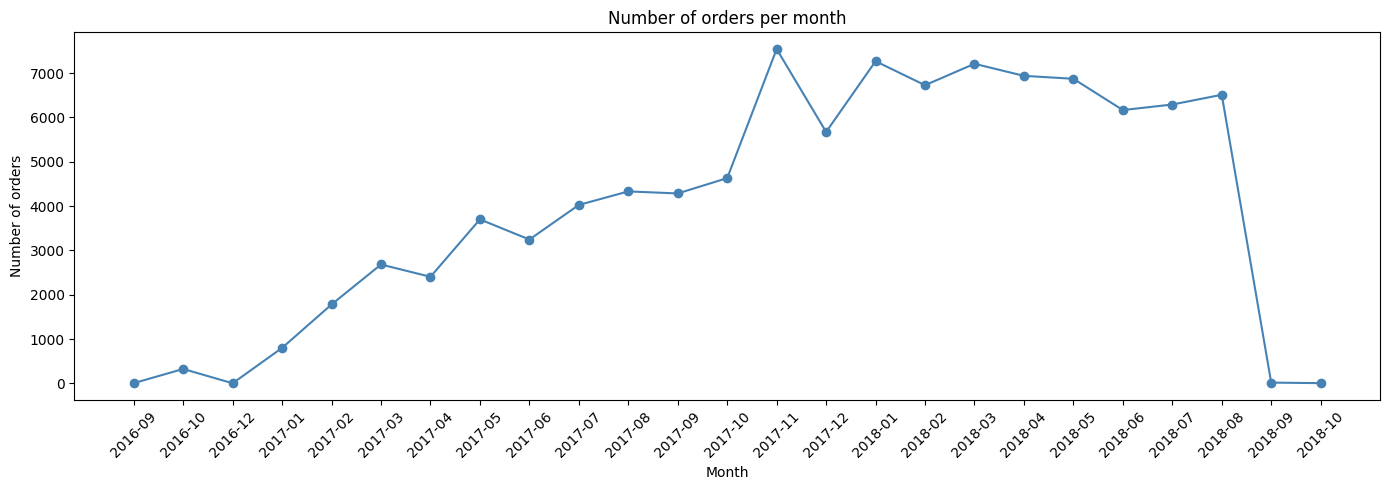

In [2]:
# Convert date from string to datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Extract year and month
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Count orders per month
orders_per_month = orders.groupby('year_month').size().reset_index(name='order_count')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(orders_per_month['year_month'].astype(str), orders_per_month['order_count'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of orders per month')
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

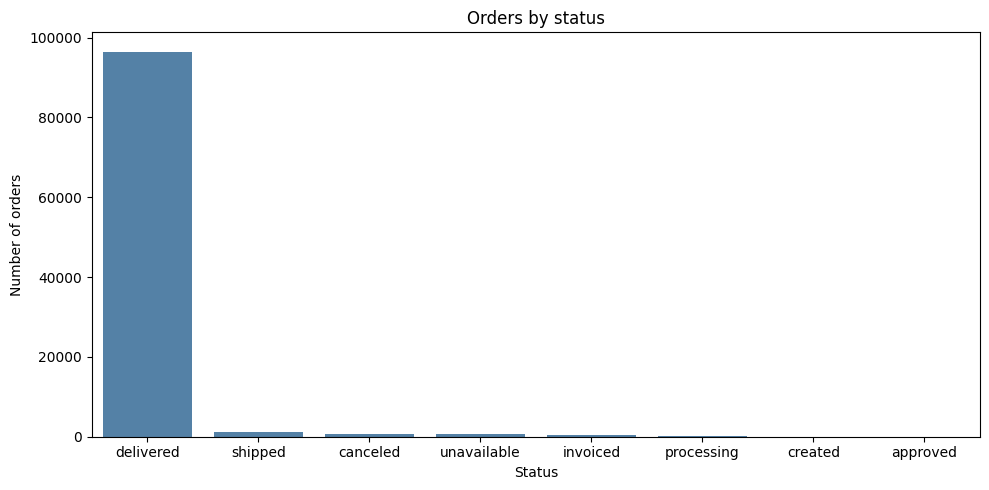

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [5]:
# Count orders by status
status_counts = orders['order_status'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=status_counts.index, y=status_counts.values, color='steelblue')
plt.title('Orders by status')
plt.xlabel('Status')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()

# Print exact numbers
print(status_counts)

Average delivery time (days): 12.1
Median delivery time (days): 10.0
Max delivery time (days): 209.0


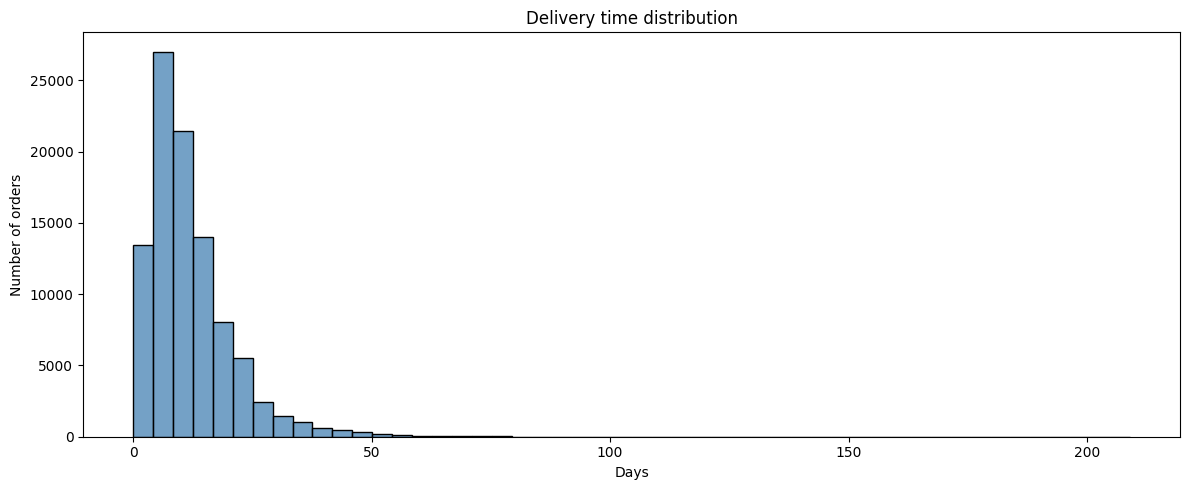

In [6]:
# Convert date columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Calculate delivery time in days
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

# Remove nulls (undelivered orders)
delivered = orders.dropna(subset=['delivery_days'])

# Basic stats
print("Average delivery time (days):", round(delivered['delivery_days'].mean(), 1))
print("Median delivery time (days):", round(delivered['delivery_days'].median(), 1))
print("Max delivery time (days):", delivered['delivery_days'].max())

# Plot distribution
plt.figure(figsize=(12, 5))
sns.histplot(delivered['delivery_days'], bins=50, color='steelblue')
plt.title('Delivery time distribution')
plt.xlabel('Days')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.show()


Average delivery time by review score:
review_score
1    20.8
2    16.2
3    13.8
4    11.8
5    10.2
Name: delivery_days, dtype: float64


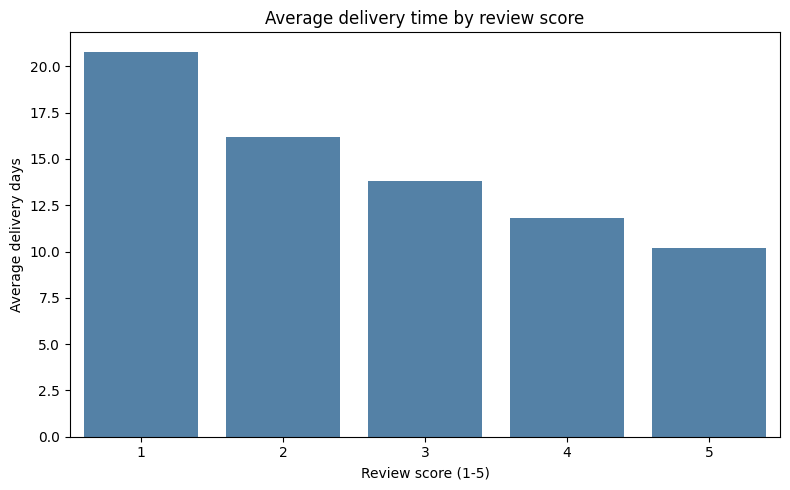

In [7]:
# Load reviews dataset
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')

# Merge orders with reviews
merged = orders.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

# Remove nulls
merged = merged.dropna(subset=['delivery_days', 'review_score'])

# Average delivery time per review score
avg_delivery = merged.groupby('review_score')['delivery_days'].mean().round(1)
print("Average delivery time by review score:")
print(avg_delivery)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_delivery.index, y=avg_delivery.values, color='steelblue')
plt.title('Average delivery time by review score')
plt.xlabel('Review score (1-5)')
plt.ylabel('Average delivery days')
plt.tight_layout()
plt.show()


In [8]:
# ── Project Summary ──────────────────────────────────────────
# Dataset: Olist Brazilian E-Commerce (99,441 orders, 2016-2018)
#
# Key findings:
# 1. Orders grew rapidly — peak in November 2017 (Black Friday effect)
# 2. 97% of orders were successfully delivered (96,478 out of 99,441)
# 3. Average delivery time: 12.1 days | Median: 10 days | Max: 209 days
# 4. Strong correlation between delivery time and review score:
#    - 1-star reviews → avg 20.8 days delivery
#    - 5-star reviews → avg 10.2 days delivery
#
# Conclusion:
# Faster delivery is the single biggest driver of customer satisfaction.
# Reducing delivery time by ~10 days could significantly improve ratings.
# ─────────────────────────────────────────────────────────────
print("Analysis complete.")

Analysis complete.
